In [3]:
print("omar")

omar


In [5]:
pip list

Package                   Version
------------------------- --------------
absl-py                   2.3.1
aiohappyeyeballs          2.6.1
aiohttp                   3.13.2
aiosignal                 1.4.0
altair                    6.0.0
annotated-types           0.7.0
anyio                     4.12.0
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.0
astunparse                1.6.3
async-lru                 2.0.5
async-timeout             5.0.1
attrs                     25.4.0
babel                     2.17.0
beautifulsoup4            4.14.2
bleach                    6.3.0
blinker                   1.9.0
blis                      1.3.3
cachetools                6.0.0
camel_tools               1.5.7
catalogue                 2.0.10
certifi                   2025.10.5
cffi                      2.0.0
charset-normalizer        3.4.3
click                     8.3.0
cloudpathlib              0.23.0
cmake           

[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


LookupError: 
**********************************************************************
  Resource [93mstopwords[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('stopwords')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mcorpora/stopwords[0m

  Searched in:
    - 'C:\\Users\\love Yemen/nltk_data'
    - 'C:\\Users\\love Yemen\\anaconda3\\envs\\myenv\\nltk_data'
    - 'C:\\Users\\love Yemen\\anaconda3\\envs\\myenv\\share\\nltk_data'
    - 'C:\\Users\\love Yemen\\anaconda3\\envs\\myenv\\lib\\nltk_data'
    - 'C:\\Users\\love Yemen\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


In [7]:
import re

# قائمة كلمات التوقف العربية الشائعة (يدوية لتجاوز خطأ التحميل)
arabic_stopwords = {
    "من", "إلى", "عن", "على", "في", "وهو", "هي", "كان", "كانت", "ان", "انها",
    "الذي", "التي", "اللذين", "اللذان", "هذا", "هذه", "هؤلاء", "لكن", "ثم", "أو",
    "قد", "لقد", "كل", "بعض", "مع", "عند", "بين"
}

def clean_arabic_text(text):
    # 1. إزالة الروابط والرموز والأرقام
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    
    # 2. توحيد الحروف (Normalization)
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "ء", text)
    text = re.sub("ئ", "ء", text)
    text = re.sub("ة", "ه", text)
    
    # 3. إزالة التشكيل
    tashkeel = re.compile(r'[\u064B-\u0652]')
    text = re.sub(tashkeel, '', text)
    
    # 4. إزالة كلمات التوقف (بناءً على القائمة أعلاه)
    words = text.split()
    words = [w for w in words if w not in arabic_stopwords]
    
    return " ".join(words)

# تجربة الكود مرة أخرى
test_sentence = "اللاعب محمد صلاح يسجل هدفاً في مباراة رياضية هامة!"
print(f"النص المنظف: {clean_arabic_text(test_sentence)}")

النص المنظف: اللاعب محمد صلاح يسجل هدفا مباراه رياضيه هامه


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

# 1. تجهيز بيانات تدريب بسيطة (جمل محددة لكل فئة)
data = [
    ("فاز الفريق بالبطولة بعد مباراة حماسية", "رياضة"),
    ("سجل اللاعب هدفا قاتلا في الدقيقة التسعين", "رياضة"),
    ("انطلقت تدريبات النادي الاستعدادية للموسم الجديد", "رياضة"),
    
    ("عقدت الحكومة اجتماعا لمناقشة الميزانية الجديدة", "سياسة"),
    ("صرح الوزير عن خطة دبلوماسية لحل الأزمة", "سياسة"),
    ("انتخابات برلمانية لاختيار أعضاء المجلس الجدد", "سياسة"),
    
    ("أفضل روتين للعناية بالبشرة في فصل الصيف", "جمال وترفيه"),
    ("أحدث صيحات الموضة لفساتين السهرة هذا العام", "جمال وترفيه"),
    ("نصائح ذهبية للحفاظ على نضارة الوجه والجمال", "جمال وترفيه")
]

# تحويل البيانات إلى قوائم (نصوص وتصنيفات) مع تنظيفها باستخدام دالتنا السابقة
texts = [clean_arabic_text(d[0]) for d in data]
labels = [d[1] for d in data]

# 2. بناء النموذج (Pipeline)
# يقوم هذا النموذج بتحويل النص لأرقام ثم تصنيفه باستخدام Naive Bayes
model = make_pipeline(TfidfVectorizer(), MultinomialNB())

# 3. تدريب النموذج
model.fit(texts, labels)

# 4. تجربة النموذج على خبر جديد تماماً!
new_news = "اجتماع طارئ بين رؤساء الدول لبحث التعاون العسكري"
cleaned_new = clean_arabic_text(new_news)
prediction = model.predict([cleaned_new])

print(f"الخبر: {new_news}")
print(f"التصنيف المتوقع: {prediction[0]}")

الخبر: اجتماع طارئ بين رؤساء الدول لبحث التعاون العسكري
التصنيف المتوقع: جمال وترفيه



   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ------------------- 1/2 [kagglehub]
   ---------------------------------------- 2/2 [kagglehub]



In [14]:
import sys
import subprocess

# استخدام الكود البرمجي للتثبيت لتجنب مشاكل المسافات في الـ Terminal
subprocess.check_call([sys.executable, "-m", "pip", "install", "kagglehub"])

print("تم التثبيت بنجاح!")

تم التثبيت بنجاح!


In [1]:
import kagglehub
import os
import pandas as pd

# 1. تحميل البيانات من Kaggle
try:
    path = kagglehub.dataset_download("asmaaabdelwahab/arabic-news-dataset")
    print("✅ تم التحميل بنجاح!")
    
    # 2. البحث عن ملف الـ CSV داخل المجلد (يتعامل مع المسافات تلقائياً)
    csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
    
    if csv_files:
        file_path = os.path.join(path, csv_files[0])
        # قراءة البيانات
        df = pd.read_csv(file_path)
        print(f"✅ تم قراءة الملف: {csv_files[0]}")
        print(f"📊 حجم البيانات: {df.shape[0]} خبر")
        
        # عرض أول 5 أسطر للتأكد من الأعمدة
        display(df.head())
    else:
        print("❌ لم يتم العثور على ملفات CSV في المجلد.")
        
except Exception as e:
    print(f"⚠️ حدث خطأ: {e}")

100%|██████████| 8.83M/8.83M [01:13<00:00, 126kB/s]

Extracting files...


✅ تم التحميل بنجاح!
✅ تم قراءة الملف: processed_data.csv
📊 حجم البيانات: 8399 خبر


,Title,Content,Link,Category
0,تيرتل تري لابز للتقنيات الحيويه تحصل علي تمويل...,جاءت جوله التمويل التمهيديه الاولي للشركه بقيا...,https://ryadiybusiness.com/%d8%aa%d9%8a%d8%b1%...,ريادة أعمال
1,تعد دراسه الجدوي لمشروعك الناشء 6 عوامل اساسيه,تعد دراسه الجدوي متطلبا اساسيا لنجاح اي مشروع ...,https://ryadiybusiness.com/%d9%83%d9%8a%d9%81-...,ريادة أعمال
2,منح جاءزه نوبل الطب لاكتشاف مجال التهاب الكبد ...,وقالت لجنه نوبل للمره الاولي التاريخ يمكن الان...,https://arabic.sputniknews.com/science/2020100...,علوم وتكنولوجيا
3,هيءه الغذاء والدواء الامريكيه لقاح مودرنا حقق ...,نشرت الوكاله وثاءق علي الانترنت اعدها موظفوها ...,https://arabic.sputniknews.com/world/202012151...,علوم وتكنولوجيا
4,حظر بروتين الجهاز المناعي يساعد علي محاربه عدو...,دراسه حديثه قام فريق العلماء جونز هوبكنز ميديس...,https://arabic.rt.com//technology/1161864-%D8%...,علوم وتكنولوجيا


In [3]:
import re
import pandas as pd

# 1. تعريف كلمات التوقف (Stopwords) يدوياً لتجنب مشاكل التحميل
arabic_stopwords = {
    "من", "إلى", "عن", "على", "في", "وهو", "هي", "كان", "كانت", "ان", "انها",
    "الذي", "التي", "اللذين", "اللذان", "هذا", "هذه", "هؤلاء", "لكن", "ثم", "أو",
    "قد", "لقد", "كل", "بعض", "مع", "عند", "بين", "علي", "كانت", "بنسبة", "بعد"
}

# 2. دالة التنظيف المحدثة
def clean_news(text):
    if pd.isna(text): return "" 
    
    # تحويل النص لسلسلة نصية (String)
    text = str(text)
    
    # إزالة الروابط
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # إزالة الرموز والتشكيل
    text = re.sub(r'[^\w\s]', '', text)
    tashkeel = re.compile(r'[\u064B-\u0652]')
    text = re.sub(tashkeel, '', text)
    
    # توحيد الحروف (Normalization)
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ة", "ه", text)
    text = re.sub("ى", "ي", text)
    
    # حذف كلمات التوقف
    words = text.split()
    words = [w for w in words if w not in arabic_stopwords]
    
    return " ".join(words)

# 3. تطبيق التنظيف على البيانات
print("جاري تنظيف البيانات... انتظر قليلاً")
df['cleaned_content'] = df['Content'].apply(clean_news)

# عرض النتيجة للتأكد
print("تم التنظيف بنجاح!")
display(df[['Content', 'cleaned_content', 'Category']].head())

جاري تنظيف البيانات... انتظر قليلاً
تم التنظيف بنجاح!


,Content,cleaned_content,Category
0,جاءت جوله التمويل التمهيديه الاولي للشركه بقيا...,جاءت جوله التمويل التمهيديه الاولي للشركه بقيا...,ريادة أعمال
1,تعد دراسه الجدوي متطلبا اساسيا لنجاح اي مشروع ...,تعد دراسه الجدوي متطلبا اساسيا لنجاح اي مشروع ...,ريادة أعمال
2,وقالت لجنه نوبل للمره الاولي التاريخ يمكن الان...,وقالت لجنه نوبل للمره الاولي التاريخ يمكن الان...,علوم وتكنولوجيا
3,نشرت الوكاله وثاءق علي الانترنت اعدها موظفوها ...,نشرت الوكاله وثاءق الانترنت اعدها موظفوها بالت...,علوم وتكنولوجيا
4,دراسه حديثه قام فريق العلماء جونز هوبكنز ميديس...,دراسه حديثه قام فريق العلماء جونز هوبكنز ميديس...,علوم وتكنولوجيا


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score

# 1. تحديد المدخلات والمخرجات
# X هو نص الخبر المنظف، و y هو التصنيف (Category)
X = df['cleaned_content']
y = df['Category']

# 2. تقسيم البيانات (80% للتدريب و 20% للاختبار)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. بناء خط إنتاج (Pipeline): 
# الجزء الأول (Tfidf): يحول الكلمات إلى أرقام تعبر عن أهميتها
# الجزء الثاني (MultinomialNB): الخوارزمية التي تتنبأ بالتصنيف
model = make_pipeline(TfidfVectorizer(), MultinomialNB())

# 4. تدريب النموذج على البيانات
print("جاري تدريب النموذج... انتظر لحظات")
model.fit(X_train, y_train)

# 5. اختبار النموذج وحساب الدقة
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"✅ تم التدريب بنجاح!")
print(f"🎯 دقة النموذج الإجمالية: {accuracy * 100:.2f}%")
print("\n--- تقرير الأداء التفصيلي ---")
print(classification_report(y_test, y_pred))

جاري تدريب النموذج... انتظر لحظات
✅ تم التدريب بنجاح!
🎯 دقة النموذج الإجمالية: 94.94%

--- تقرير الأداء التفصيلي ---
                 precision    recall  f1-score   support

           أخرى       0.92      0.99      0.96       545
    ريادة أعمال       0.94      0.97      0.96       561
علوم وتكنولوجيا       0.98      0.89      0.94       574

       accuracy                           0.95      1680
      macro avg       0.95      0.95      0.95      1680
   weighted avg       0.95      0.95      0.95      1680



In [5]:
# تجربة خبر جديد
new_text = "أطلقت شركة آبل معالجاً جديداً يدعم تقنيات الذكاء الاصطناعي"
cleaned_new = clean_news(new_text) # تنظيف الخبر أولاً
prediction = model.predict([cleaned_new])

print(f"الخبر: {new_text}")
print(f"التصنيف المتوقع من النموذج هو: {prediction[0]}")

الخبر: أطلقت شركة آبل معالجاً جديداً يدعم تقنيات الذكاء الاصطناعي
التصنيف المتوقع من النموذج هو: ريادة أعمال


In [6]:
print(df['Category'].value_counts())

Category
علوم وتكنولوجيا    2800
أخرى               2800
ريادة أعمال        2799
Name: count, dtype: int64


In [8]:
import sys
import subprocess

# تثبيت المكتبات اللازمة للرسم البياني
subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn", "matplotlib"])
print("✅ تم تثبيت المكتبات بنجاح!")

✅ تم تثبيت المكتبات بنجاح!


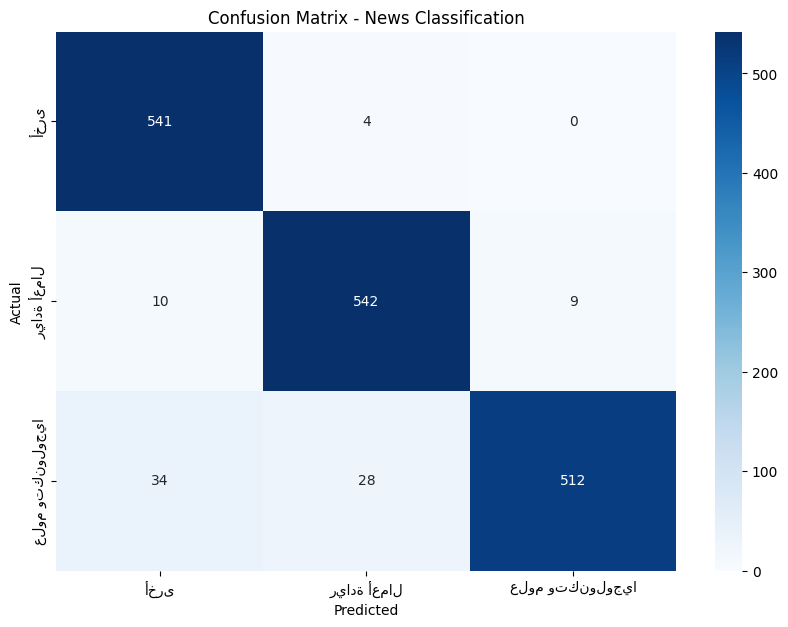

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. حساب مصفوفة الارتباك بناءً على توقعات النموذج السابقة
# y_test: التصنيفات الحقيقية ، y_pred: توقعات النموذج
cm = confusion_matrix(y_test, y_pred)
categories = model.classes_ # أسماء الفئات (تكنولوجيا، ريادة أعمال، أخرى)

# 2. إعداد شكل الرسم
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=categories, yticklabels=categories, cmap='Blues')

# 3. إضافة العناوين (باللغة الإنجليزية لتجنب مشاكل الخطوط العربية في matplotlib حالياً)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - News Classification')
plt.show()